In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
from scipy import stats
import sqlite3

In [48]:
Data = pd.read_excel('CanadaCEData.xlsx',sheet_name='Data',header=1)
Data.set_index(['Cultivar','TmeanFinal','PpInitial','PpFinal','TmeanInitial','DuratInitial'],drop=False,inplace=True)
Data.sort_index(axis=0,inplace=True)
Data.sort_index(axis=1,inplace=True)

In [49]:
Cultivars = Data.index.get_level_values(0).drop_duplicates()
InitTemps = Data.index.get_level_values(4).drop_duplicates()
InitPps = Data.index.get_level_values(2).drop_duplicates()
FinalTemps = Data.index.get_level_values(1).drop_duplicates()
FinalPps = Data.index.get_level_values(3).drop_duplicates()

In [13]:
Cultivars

Index(['Percoz', 'Liard'], dtype='object', name='Cultivar')

In [16]:
InitTemps

Index([1, 5, 9], dtype='int64', name='TmeanInitial')

In [19]:
InitPps

Index([8, 16], dtype='int64', name='PpInitial')

In [21]:
FinalTemps

Index([12, 19], dtype='int64', name='TmeanFinal')

In [24]:
FinalPps

Index([11, 16], dtype='int64', name='PpFinal')

In [76]:
cols = dict(zip(InitTemps.values,['b','g','r']))
fill = dict(zip(InitPps.values,[False,True]))
lins = dict(zip(InitPps.values,['o--','o-']))
ylims = dict(zip(Cultivars.values,[(500,2000),(300,1000)]))

In [82]:
Data

Cultivar  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial            
Liard    12         8         11      1            0               Liard   
                                                   10              Liard   
                                                   30              Liard   
                                                   60              Liard   
                                      5            0               Liard   
...                                                                  ...   
Percoz   19         16        16      5            60             Percoz   
                                      9            0              Percoz   
                                                   10             Percoz   
                                                   30             Percoz   
                                                   60             Percoz   

                                                                 DaysToFlowerInFinal  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial                        
Liard    12         8         11      1            0                      104.111498   
                                                   10                      96.585366   
                                                   30                      87.386760   
                                                   60                      83.623693   
                                      5            0                      104.111498   
...                                                                              ...   
Percoz   19         16        16      5            60                      13.159574   
                                      9            0                       29.287929   
                                                   10                      26.341277   
                                                   30                      15.419543   
                                                   60                       7.114157   

                                                                 DuratInitial  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial                 
Liard    12         8         11      1            0                        0   
                                                   10                      10   
                                                   30                      30   
                                                   60                      60   
                                      5            0                        0   
...                                                                       ...   
Percoz   19         16        16      5            60                      60   
                                      9            0                        0   
                                                   10                      10   
                                                   30                      30   
                                                   60                      60   

                                                                 PpFinal  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial            
Liard    12         8         11      1            0                  11   
                                                   10                 11   
                                                   30                 11   
                                                   60                 11   
                                      5            0                  11   
...                                                                  ...   
Percoz   19         16        16      5            60                 16   
                                      9            0                  16   
                                                   10                 16   
                                        

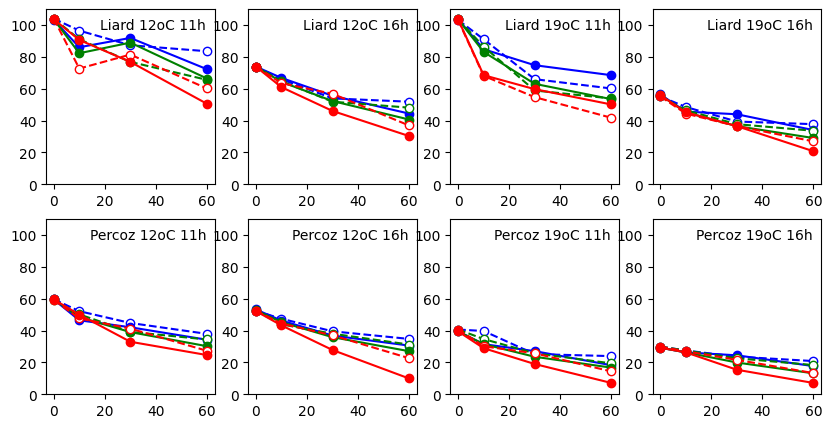

In [85]:
Graph = plt.figure(figsize=(10,5))
pos = 1
for c in Cultivars:
    for ft in FinalTemps:
        for fp in FinalPps:
            ax = Graph.add_subplot(2,4,pos)
            plt.text(0.95,0.95,c+" "+str(ft)+"oC "+str(fp)+"h",horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
            for it in InitTemps:
                for ip in InitPps:
                    datfilter = (Data.Cultivar==c)&(Data.TmeanFinal==ft)&(Data.PpFinal==fp)&(Data.TmeanInitial==it)&(Data.PpInitial==ip)
                    dat = Data.loc[datfilter,:]
                    fc = cols[it]
                    ls = lins[ip]
                    if ip == 8:
                        fc = 'w'
                    plt.plot(dat.DuratInitial,dat.DaysToFlowerInFinal,ls,color = cols[it],mfc=fc)
            #plt.ylim(ylims[c][0],ylims[c][1])
            plt.ylim(0,110)
            pos+=1

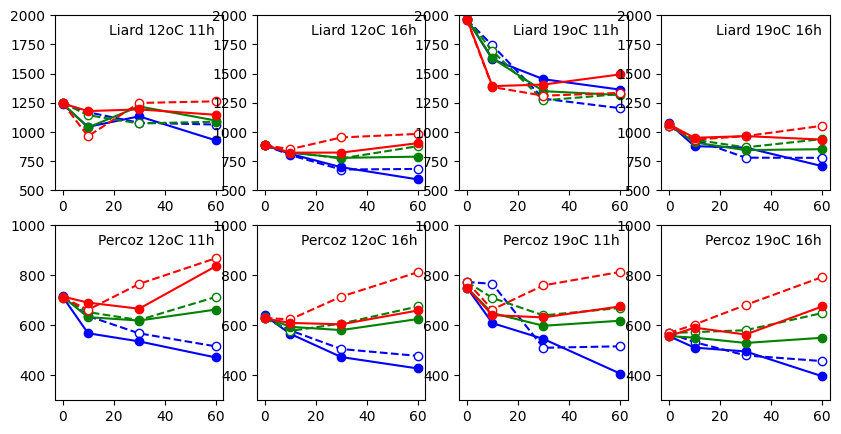

In [86]:
Graph = plt.figure(figsize=(10,5))
pos = 1
for c in Cultivars:
    for ft in FinalTemps:
        for fp in FinalPps:
            ax = Graph.add_subplot(2,4,pos)
            plt.text(0.95,0.95,c+" "+str(ft)+"oC "+str(fp)+"h",horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
            for it in InitTemps:
                for ip in InitPps:
                    datfilter = (Data.Cultivar==c)&(Data.TmeanFinal==ft)&(Data.PpFinal==fp)&(Data.TmeanInitial==it)&(Data.PpInitial==ip)
                    dat = Data.loc[datfilter,:]
                    fc = cols[it]
                    ls = lins[ip]
                    if ip == 8:
                        fc = 'w'
                    plt.plot(dat.DuratInitial,dat.TtFirstFlower,ls,color = cols[it],mfc=fc)
            plt.ylim(ylims[c][0],ylims[c][1])
            pos+=1